# **Capítulo 3: Señal exponencial compleja y Series de Fourier**

```
 Libro:  Analisis de Señales Utilizando Python
```


**Autor:  Dora María Ballesteros Larrotta**  
Universidad Militar Nueva Granada (UMNG)

---

### Material complementario del libro

Este notebook acompaña el **Capítulo 3** y contiene los ejemplos desarrollados a lo largo del texto. Se recomienda seguir el mismo orden del libro para obtener el máximo provecho de las actividades propuestas.

# **Ejemplo 21. Manipulación de exponenciales complejas**

Figura 64

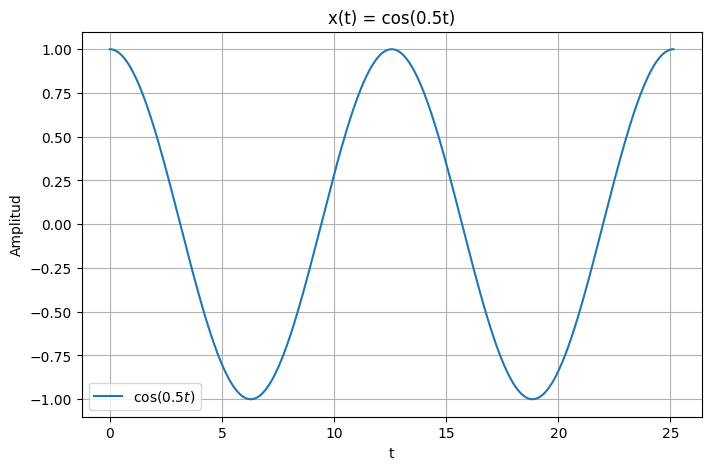

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Definir el rango de tiempo
t = np.linspace(0, 8 * np.pi, 1000)

# Calcular la señal x(t)
x = np.cos(0.5 * t)

# Graficar la señal
plt.figure(figsize=(8, 5))
plt.plot(t, x, label=r'$\cos(0.5t)$')
plt.xlabel('t')
plt.ylabel('Amplitud')
plt.title('x(t) = cos(0.5t)')
plt.grid(True)
plt.legend()
plt.show()



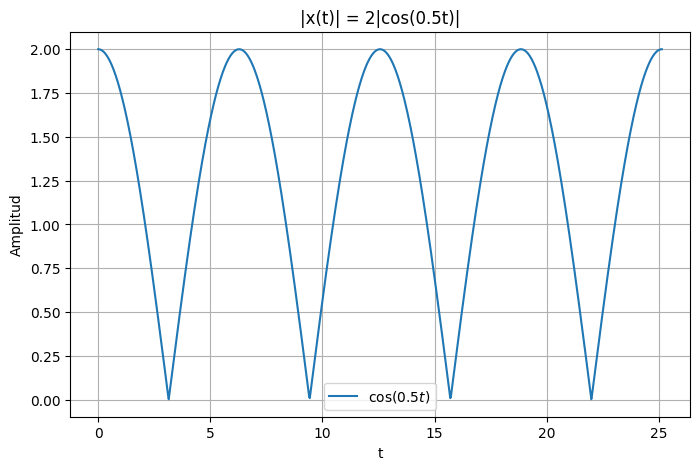

In [2]:
# Calcular la magnitud de la señal
x = 2 * np.abs(np.cos(0.5 * t))

# Graficar la señal
plt.figure(figsize=(8, 5))
plt.plot(t, x, label=r'$\cos(0.5t)$')
plt.xlabel('t')
plt.ylabel('Amplitud')
plt.title('|x(t)| = 2|cos(0.5t)|')
plt.grid(True)
plt.legend()
plt.show()

# **Ejemplo 24. Serie de Fourier de una señal cuadrada periódica**

el valor de D.C. de la señal, es: 0.19999999999999998


<StemContainer object of 3 artists>

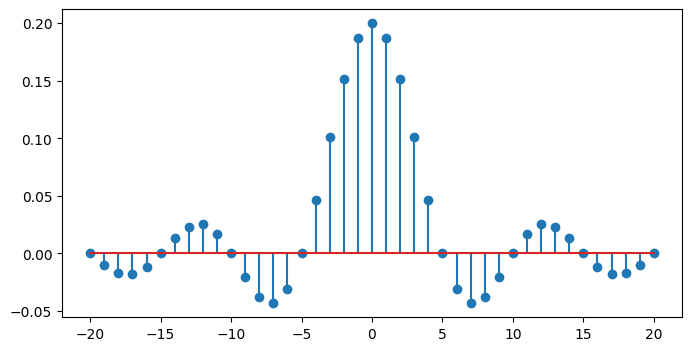

In [3]:
import numpy as np
import matplotlib.pyplot as plt
num=20
coef = np.arange(-num,num+1)
a = np.zeros((len(coef),1))

T1=0.01
T = 10*T1
w0=2*np.pi/T
a0=2*T1/T
print("el valor de D.C. de la señal, es:", a0)

count=0
for k in range(-num,num+1):
  if k==0:
    a[count]=a0
  else:
    a[count]=np.sin(k*w0*T1)/(k*np.pi)
  count=count+1

plt.rcParams["figure.figsize"] = (8,4)
plt.stem(coef, a)


# **Ejemplo 25. Serie de Fourier de un tren de impulsos**

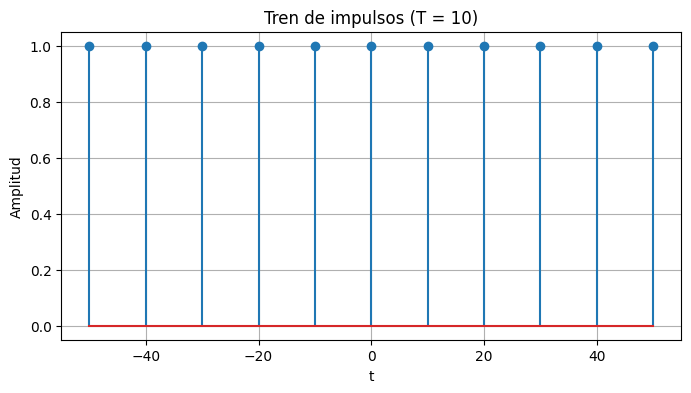

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Parámetros
T = 10
n = np.arange(-5, 6)  # 11 impulsos: desde -5T hasta 5T
t_imp = n * T         # posiciones de los impulsos

# Gráfica
plt.figure()
plt.stem(t_imp, np.ones_like(t_imp))

plt.title('Tren de impulsos (T = 10)')
plt.xlabel('t')
plt.ylabel('Amplitud')
plt.grid()

plt.show()

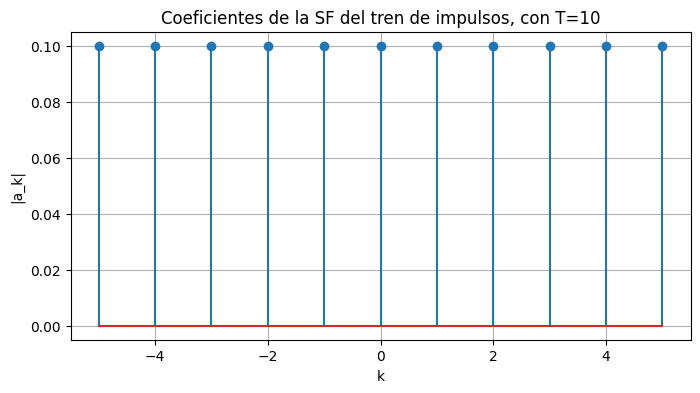

In [5]:
# Valores de k
k = np.arange(-5, 6)

# Coeficientes ak
ak = (1/T) * np.ones_like(k)

# Gráfica
plt.figure()
plt.stem(k, ak)

plt.title('Coeficientes de la SF del tren de impulsos, con T=10')
plt.xlabel('k')
plt.ylabel('|a_k|')
plt.grid()

plt.show()

# **Ejemplo 26. Fenómeno de Gibbs señal cuadrada**

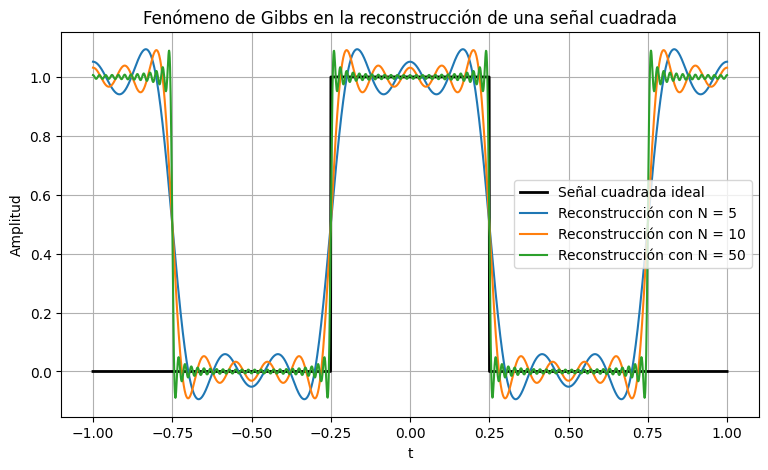

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Parámetros de la señal
T = 1                 # Periodo
T1 = T / 4            # Ancho del pulso
w0 = 2 * np.pi / T    # Frecuencia fundamental

# Eje de tiempo
t = np.linspace(-T, T, 2000)

# Señal cuadrada ideal
x = np.where(np.abs(t) < T1, 1, 0)

# Función para reconstrucción con N armónicas
def fourier_reconstruction(t, N):
    x_rec = np.zeros_like(t, dtype=float)

    # Coeficiente DC
    a0 = 2 * T1 / T
    x_rec += a0

    # Armónicas
    for k in range(1, N + 1):
        ak = np.sin(k * w0 * T1) / (k * np.pi)
        x_rec += 2 * ak * np.cos(k * w0 * t)

    return x_rec

# Número de armónicas a usar
N_values = [5, 10, 50]

# Gráfica
plt.figure(figsize=(9, 5))
plt.plot(t, x, 'k', linewidth=2, label='Señal cuadrada ideal')

for N in N_values:
    plt.plot(t, fourier_reconstruction(t, N),
             label=f'Reconstrucción con N = {N}')

plt.xlabel('t')
plt.ylabel('Amplitud')
plt.title('Fenómeno de Gibbs en la reconstrucción de una señal cuadrada')
plt.legend()
plt.grid(True)
plt.show()

# **Ejemplo 29. Cálculo de los coeficientes de la Serie de Fourier de una señal periódica formada por componentes senoidales armónicamente relacionados**

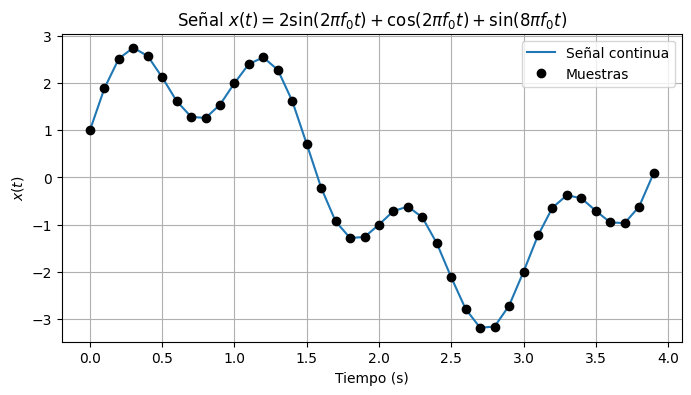

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# Parámetros de la señal
fo = 1/4  # frecuencia fundamental de la señal [Hz]
fs = 40 * fo  # frecuencia de muestreo (cumple Nyquist)
ciclos = 1  # cantidad de ciclos a visualizar
stop = ciclos / fo  # tiempo final
ns = int(stop * fs)  # número de muestras

# Vector de tiempo (alineado exactamente con la fs)
t = np.arange(0, stop, 1/fs)

# Definición de la señal
x = 2*np.sin(2*np.pi*fo*t) + np.cos(2*np.pi*fo*t) + np.sin(4*2*np.pi*fo*t)

# Configuración de la figura
plt.rcParams["figure.figsize"] = (8,4)

# Gráfica
plt.plot(t, x, label='Señal continua')
plt.plot(t, x, 'ko', label='Muestras')

plt.xlabel('Tiempo (s)')
plt.ylabel('$x(t)$')
plt.title(r'Señal $x(t)=2\sin(2\pi f_0 t)+\cos(2\pi f_0 t)+\sin(8\pi f_0 t)$')

plt.grid(True)
plt.legend()
plt.show()

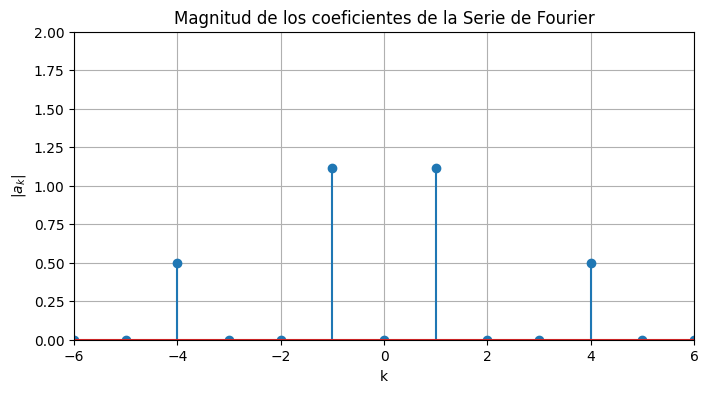

In [8]:
from scipy.fft import fft, fftfreq
import numpy as np
import matplotlib.pyplot as plt

# número de muestras
n = len(x)

# Serie de Fourier
ak = fft(x) / n
k = fftfreq(n, 1/fs)

# posiciones armónicas
k = k / fo

# Configurar la visualización
plt.stem(k, np.abs(ak))
plt.xlim(-6, 6)
plt.ylim(0, 2)

plt.xlabel('k')
plt.ylabel(r'$|a_k|$')
plt.title('Magnitud de los coeficientes de la Serie de Fourier')

plt.grid(True)
plt.show()

#**Ejemplo 30. Cálculo de los coeficientes de la SF de una señal periódica expresada como producto de cosenos**

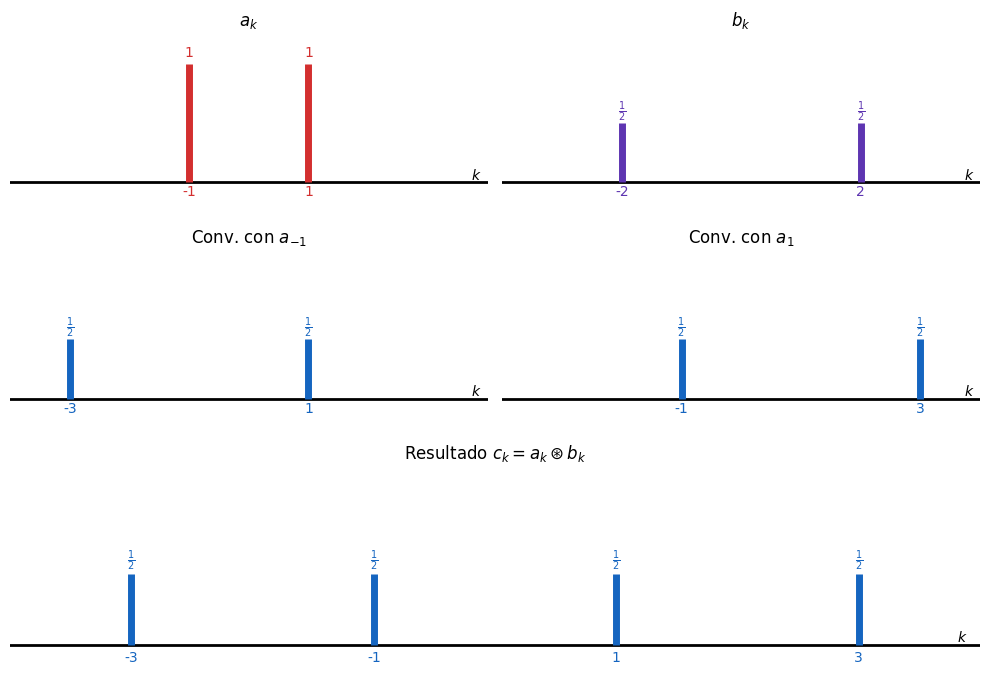

In [9]:
import numpy as np
import matplotlib.pyplot as plt

COL_A, COL_B, COL_C = "#D32F2F", "#5E35B1", "#1565C0"

def impulses(ax, k, a, col, title=""):
    ax.axhline(0, color="black", lw=2)
    ax.set_xlim(-4,4); ax.set_ylim(-0.25,1.25)
    ax.set_xticks([]); ax.set_yticks([])
    for s in ax.spines.values(): s.set_visible(False)

    for ki, ai in zip(k,a):
        ax.vlines(ki,0,ai,color=col,lw=5)
        txt = r"$\frac{1}{2}$" if np.isclose(ai,0.5) else f"{ai:g}"
        ax.text(ki,ai+0.06,txt,ha="center",color=col)
        ax.text(ki,-0.12,f"{int(ki)}",ha="center",color=col)

    ax.text(3.9,0.02,"$k$",ha="right")
    ax.set_title(title)

# coeficientes
ka, aa = np.array([-1,1]), np.array([1,1])
kb, bb = np.array([-2,2]), np.array([0.5,0.5])

# convolución
k1, c1 = kb-1, bb
k2, c2 = kb+1, bb

# resultado final
k = np.array([-3,-1,1,3])
c = np.array([0.5,0.5,0.5,0.5])

# figura
fig = plt.figure(figsize=(10,7))
gs = fig.add_gridspec(3,2, height_ratios=[1,1,1.2])

ax1 = fig.add_subplot(gs[0,0])
ax2 = fig.add_subplot(gs[0,1])
ax3 = fig.add_subplot(gs[1,0])
ax4 = fig.add_subplot(gs[1,1])
ax5 = fig.add_subplot(gs[2,:])   # ocupa todo el ancho

impulses(ax1,ka,aa,COL_A,"$a_k$")
impulses(ax2,kb,bb,COL_B,"$b_k$")
impulses(ax3,k1,c1,COL_C,"Conv. con $a_{-1}$")
impulses(ax4,k2,c2,COL_C,"Conv. con $a_{1}$")
impulses(ax5,k,c,COL_C,"Resultado $c_k = a_k \\circledast b_k$")

plt.tight_layout()
plt.show()

Libro: Analisis de Señales Utilizando Python

---


Versión: 2026 – Material complementario para Google Colab.